In [28]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [29]:
!pip install thop
!pip install tdqm

# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [3]:


def scaled_dot_attention(q, k, v, mask=0):
  """Computes scaled dot product attention with an optional mask.
    q : shape ( batch, k, hidden_size)
    k : shape ( batch, seq_len, hidden_size)
    v : shape ( batch, seq_len, hidden_size)
    mask: optional. shape (k, seq_len)

  returns:
      context   : shape (batch, k, hidden_size)
      attention : shape (batch, k, seq_len)
  """

  # ------------
  # FILL THIS IN
  # ------------
  _, _, hidden_size = q.shape
  k_t = k.transpose(1, 2)
  unnorm_attn = torch.bmm(q, k_t)
  masked_unnorm_attn = unnorm_attn + mask
  attention = nn.Softmax(dim=2)(masked_unnorm_attn / hidden_size**0.5)
  context = torch.bmm(attention, v)
  return context, attention

In [4]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size

    def forward(self, x, annots):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [21]:
class CausalAttention(Attention):
    def __init__(self, hidden_size):
        super().__init__(hidden_size)

    def forward(self, x):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        _, seq_len, _ = x.shape
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [6]:
cros_attn = Attention(32)
caus_attn = CausalAttention(32)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32)
inp2 = torch.randn(4, 16, 32)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_len = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)   # [max_len, 1]
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0) # [1, hidden_size // 2]

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)

    def forward(self, idx):
        return self.pe[idx]

In [8]:
class MLP(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()
        self.layer1  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x, annotation):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [9]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights) # initialize the weights to a small number

    def forward(self, inputs, annots):

        pos_x = torch.arange(0, inputs.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(0, annots.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {'self_attn': self_attn, 'cros_attn': cros_attn}

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [10]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.insert(0, '/content/drive/MyDrive/NNDL_hw2/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [11]:
import os
os.listdir('/content/drive/MyDrive/NNDL_hw2/')

['hw_utils.py',
 'pig_latin_small.txt',
 'pig_latin_large.txt',
 'hw_trainer.py',
 'hw_dataset.py',
 '__pycache__']

In [15]:
script_path = '/content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt'
if os.path.exists(script_path):
    print(f"File found at {script_path}")
else:
    print(f"File not found at {script_path}")

File found at /content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt


In [17]:
from hw_dataset import EncoderDecoderDataset, DecoderDataset
from hw_utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from hw_trainer import train
import torch.optim as optim

data_path = '/content/drive/MyDrive/NNDL_hw2/' # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, 'pig_latin_small')
encdec_ds_large = EncoderDecoderDataset(data_path, 'pig_latin_large')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [20]:
print("device: ", device)
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

device:  cuda
Dataset sample:
Input: <SOS>ungenerousway
Annotation: ungenerous
Target: ungenerousway<EOS>


In [22]:
model = TransformerEncoderDecoder(
    vocab_size = len(encdec_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=25,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size = 32
)

Epoch 1 | Train loss: 2.586313 | Val loss 2.302024
Epoch 2 | Train loss: 2.133266 | Val loss 2.021814
Epoch 3 | Train loss: 1.867431 | Val loss 1.792918
Epoch 4 | Train loss: 1.612247 | Val loss 1.465220
Epoch 5 | Train loss: 1.264005 | Val loss 1.101677
Epoch 6 | Train loss: 0.930958 | Val loss 0.809738
Epoch 7 | Train loss: 0.663149 | Val loss 0.617976
Epoch 8 | Train loss: 0.458753 | Val loss 0.404918
Epoch 9 | Train loss: 0.338479 | Val loss 0.323413
Epoch 10 | Train loss: 0.266926 | Val loss 0.269447
Epoch 11 | Train loss: 0.230339 | Val loss 0.247508
Epoch 12 | Train loss: 0.212453 | Val loss 0.209837
Epoch 13 | Train loss: 0.171004 | Val loss 0.173949
Epoch 14 | Train loss: 0.140889 | Val loss 0.174965
Epoch 15 | Train loss: 0.134454 | Val loss 0.174754
Epoch 16 | Train loss: 0.105639 | Val loss 0.149131
Epoch 17 | Train loss: 0.112140 | Val loss 0.173662
Epoch 18 | Train loss: 0.104658 | Val loss 0.160782
Epoch 19 | Train loss: 0.093766 | Val loss 0.125598
Epoch 20 | Train loss

In [23]:
def encdec_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor([dataset.to_idx(input) + [dataset.end_idx]*(max(0, 12-len(input)))]).to(device)
    #pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def encdec_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [24]:
encdec_translate('the', model, encdec_ds_small)

'ethay'

In [25]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'ethay airway onditioningcay isway orkingway'

In [26]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingtay omesay andomray ordsway'


Training model: hidden_size=16, dataset=small
Epoch 1 | Train loss: 2.617303 | Val loss 2.324927
Epoch 2 | Train loss: 2.135136 | Val loss 2.039259
Epoch 3 | Train loss: 1.872336 | Val loss 1.758687
Epoch 4 | Train loss: 1.573473 | Val loss 1.450878
Epoch 5 | Train loss: 1.126864 | Val loss 0.877388
Epoch 6 | Train loss: 0.780782 | Val loss 0.693219
Epoch 7 | Train loss: 0.608418 | Val loss 0.683335
Epoch 8 | Train loss: 0.497227 | Val loss 0.417538
Epoch 9 | Train loss: 0.356830 | Val loss 0.348182
Epoch 10 | Train loss: 0.303732 | Val loss 0.393057
Epoch 11 | Train loss: 0.251120 | Val loss 0.338778
Epoch 12 | Train loss: 0.255234 | Val loss 0.256530
Epoch 13 | Train loss: 0.196685 | Val loss 0.275365
Epoch 14 | Train loss: 0.182363 | Val loss 0.190458
Epoch 15 | Train loss: 0.170501 | Val loss 0.200264
Epoch 16 | Train loss: 0.148358 | Val loss 0.156187
Epoch 17 | Train loss: 0.124611 | Val loss 0.163876
Epoch 18 | Train loss: 0.128569 | Val loss 0.148827
Epoch 19 | Train loss: 0.1

<Figure size 640x480 with 0 Axes>

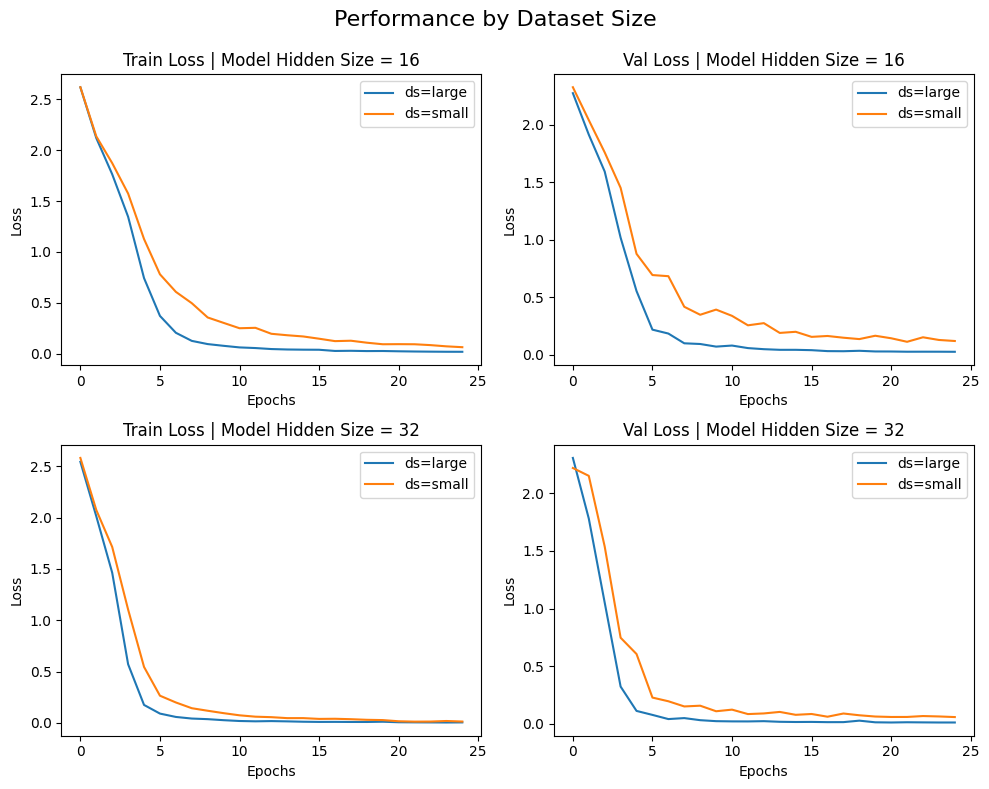

<Figure size 640x480 with 0 Axes>

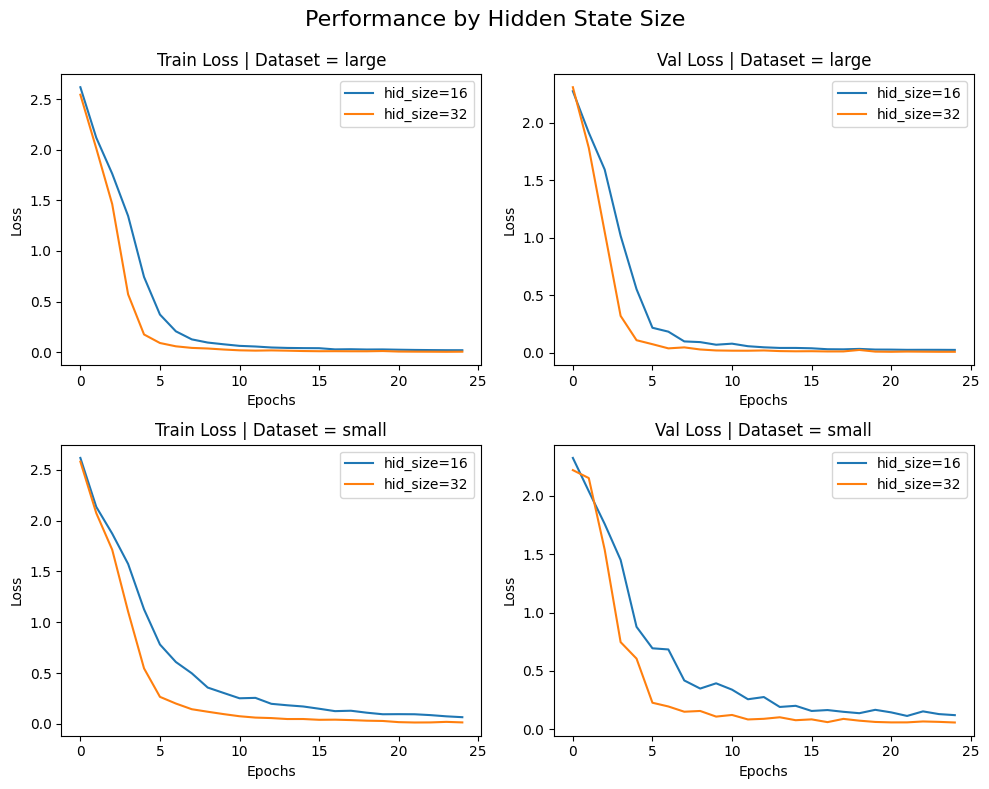

In [27]:
configs = [
    (16, 'small', encdec_ds_small),
    (16, 'large', encdec_ds_large),
    (32, 'small', encdec_ds_small),
    (32, 'large', encdec_ds_large)
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    model = TransformerEncoderDecoder(
        vocab_size=len(dataset.idx_to_token),
        hidden_size=hidden_size,
        num_layers=4
    )
    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = dataset,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = 32 if dataset_name == "small" else 256
    )
    all_results[(hidden_size, dataset_name)] = results

save_loss_comparison_by_dataset(all_results)
save_loss_comparison_by_hidden(all_results)

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [41]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

    def forward(self, inputs):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len) ? (batch_size x decoder_seq_len x num_layers)
        """
        # ------------
        # FILL THIS IN
        # ------------
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []

        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)

        unormalized_scores = self.head(x)
        # unormalized_scores = nn.Softmax(dim=2)(x)

        return unormalized_scores, {'self_attn': self_attn}

In [31]:
decoder_ds_small = DecoderDataset(data_path, 'pig_latin_small')
decoder_ds_large = DecoderDataset(data_path, 'pig_latin_large')

In [32]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>ungenerous<EOP>ungenerousway
Target: ungenerous<EOP>ungenerousway<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [39]:
def decoder_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = dataset.to_idx(input)
    idx.insert(0, dataset.start_idx)
    idx.insert(-1, dataset.eop_idx)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def decoder_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [44]:
model = DecoderTransformer(
    vocab_size = len(decoder_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model = model,
    dataset = decoder_ds_small,
    num_epochs = 100,
    optimizer = optimizer,
    scheduler = scheduler,
    device = device,
    batch_size = 32
)

Epoch 1 | Train loss: 3.035028 | Val loss 1.883953
Epoch 2 | Train loss: 1.707383 | Val loss 1.615140
Epoch 3 | Train loss: 1.480366 | Val loss 1.483366
Epoch 4 | Train loss: 1.316226 | Val loss 1.292010
Epoch 5 | Train loss: 1.117442 | Val loss 1.107031
Epoch 6 | Train loss: 0.959725 | Val loss 0.930619
Epoch 7 | Train loss: 0.867120 | Val loss 0.878117
Epoch 8 | Train loss: 0.736522 | Val loss 0.701814
Epoch 9 | Train loss: 0.623219 | Val loss 0.572482
Epoch 10 | Train loss: 0.468536 | Val loss 0.509236
Epoch 11 | Train loss: 0.359207 | Val loss 0.312492
Epoch 12 | Train loss: 0.307635 | Val loss 0.318974
Epoch 13 | Train loss: 0.251927 | Val loss 0.292040
Epoch 14 | Train loss: 0.219853 | Val loss 0.241388
Epoch 15 | Train loss: 0.195079 | Val loss 0.298505
Epoch 16 | Train loss: 0.174855 | Val loss 0.295178
Epoch 17 | Train loss: 0.161122 | Val loss 0.186059
Epoch 18 | Train loss: 0.147929 | Val loss 0.181834
Epoch 19 | Train loss: 0.150962 | Val loss 0.157857
Epoch 20 | Train loss

In [45]:
decoder_translate("the air conditioning is working", model, decoder_ds_small)

'hay ray digioonincay way kiniway'

## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [46]:


# TO DO:

def multihead_scaled_dot_attention(q, k, v, mask=0):
    """ Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    hidden_size = q.shape[-1]
    unnorm_attn = torch.matmul(q, k.transpose(2, 3))
    masked_unnorm_attn = unnorm_attn + mask
    attention = nn.Softmax(dim=2)(masked_unnorm_attn / hidden_size ** 0.5)
    context = torch.matmul(attention, v)
    return context, attention

In [48]:
class MultiheadCausalAttention(Attention):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        if self.num_heads > 1:
          self.proj = nn.Linear( hidden_size, hidden_size, bias=False)


    def forward(self, x):

        """ Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        B, T, C = x.size()
        q = self.Q(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        k = self.K(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        v = self.V(x).view( B, T, self.num_heads, -1).transpose(1, 2)

        mask = torch.triu(torch.ones(T, T), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)

        context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        reshaped_context = context.transpose(1, 2).contiguous().view( B, T, -1)

        # Only perform a projection if the number of heads is more than 1.
        if self.num_heads > 1:
          return self.proj(reshaped_context), attention
        else:
          return reshaped_context, attention

In [49]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(self, vocab_size, hidden_size, num_layers, num_heads):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [50]:
def calc_parameters_decoder(model):
  # ------------
  # FILL THIS IN
  # ------------
  # params = TODO # embedding
  # params +=  TODO # QKV linear projections
  # if model.num_heads > 1:
  #   params += TODO # attention linear projection
  # params += TODO # MLP linear
  # params += TODO # layer norms Hint: LayerNorm(x) uses x parameters

  # Hint: Read the code carefully:
  # params += TODO # head
  params = sum(p.numel() for p in model.parameters() if p.requires_grad)


  return params



Training model: hidden_size=16, num_heads=4, num_layers=4
Epoch 1 | Train loss: 2.034756 | Val loss 1.002613
Epoch 2 | Train loss: 0.646721 | Val loss 0.342656
Epoch 3 | Train loss: 0.210284 | Val loss 0.123847
Epoch 4 | Train loss: 0.080081 | Val loss 0.060820
Epoch 5 | Train loss: 0.039772 | Val loss 0.023752
Epoch 6 | Train loss: 0.022859 | Val loss 0.015079
Epoch 7 | Train loss: 0.013900 | Val loss 0.011096
Epoch 8 | Train loss: 0.010329 | Val loss 0.007627
Epoch 9 | Train loss: 0.007628 | Val loss 0.004691
Epoch 10 | Train loss: 0.004620 | Val loss 0.006813
Epoch 11 | Train loss: 0.006614 | Val loss 0.014680
Epoch 12 | Train loss: 0.003923 | Val loss 0.005605
Epoch 13 | Train loss: 0.004496 | Val loss 0.008438
Epoch 14 | Train loss: 0.002830 | Val loss 0.003152
Epoch 15 | Train loss: 0.003140 | Val loss 0.008450
Epoch 16 | Train loss: 0.005134 | Val loss 0.005436
Epoch 17 | Train loss: 0.001555 | Val loss 0.003967
Epoch 18 | Train loss: 0.001445 | Val loss 0.000272
Epoch 19 | Tra

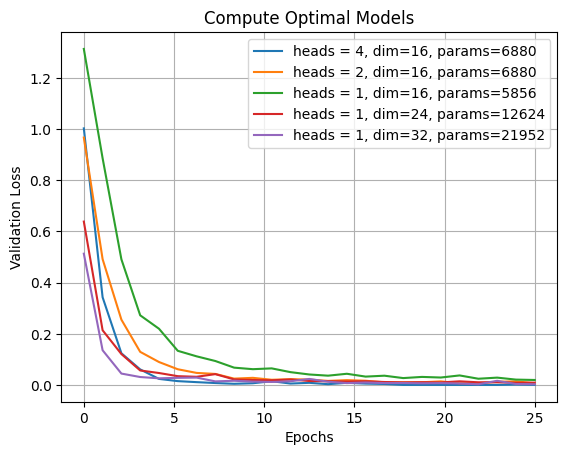

In [54]:
import matplotlib.pyplot as plt
import numpy as np
configs = [
    (16, 4, 4, 64), #(hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_large.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_large,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results['val_loss']), len(results['val_loss']))
    plt.plot(
        x_points, results['val_loss'], label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ))
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title('Compute Optimal Models')
plt.grid()
plt.legend()
plt.show()

In [ ]:
plt.clf()

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [ ]:
from utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [ ]:

configs = [
    (40, 2, 4, 256), #(hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_large.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_large,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results


In [ ]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [ ]:
def find_optim_params(params, loss):
    x = np.array(params)
    y = np.array(loss)

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10**(optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00']
params_vs_loss = []
optimal_params = []

for target in target_flops:
  parameters = []
  val_loss = []

  for params, results in all_results.items():
    loss = interpolate(results['val_loss'], results['flops'], target, deg=4)
    # interpolate returns None if target is out of range
    if loss != None:
      parameters.append(params)
      val_loss.append(loss)

  sorted_indices = torch.argsort(torch.tensor(parameters))
  parameters = torch.tensor(parameters)[sorted_indices]
  val_loss = torch.tensor(val_loss)[sorted_indices]

  optimal_params.append(find_optim_params(parameters, val_loss))
  params_vs_loss.append((parameters.tolist(), val_loss.tolist()))


In [ ]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

In [ ]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

In [ ]:
plot_flops_tokens(target_flops, optimal_params, all_results)